<a href="https://colab.research.google.com/github/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/Int_caus2026_RedesBayesianas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 4: Redes Bayesianas I


En este notebook, implementaremos redes bayesianas con ayuda de la librería pyAgrum. El dataset utilizado, que es sobre diagnósticos de COVID-19 se puede encontrar en: https://www.kaggle.com/datasets/einsteindata4u/covid19/data

Las **redes bayesianas** son una clase de Modelos Gráficos Probabilísticos populares por su capacidad de razonar bajo incertidumbre.

Pueden ser vistas como un sistema experto probabilístico: el conocimiento del dominio o problema se modela como un grafo acíclico dirigido DAG. Los enlaces (arcos) del grafo representan las dependencias probabilísticas (correlación, causalidad o influencia) entre los nodos/variables del dominio.

Más formalmente, una red bayesina es una **Distribución de Probabilidad Conjunta** sobre un conjunto de variables aleatorias. Se representa mediante un grafo, donde los nodos se identifican con variables aleatorias y los arcos expresan la dependencia probabilística entre ellos.


## Planteamiento


Para poner en perspectiva a estas redes, considere una Unidad de Cuidados Intensivos (UCI) de un hospital. Los profesionales de la salud necesitan tener una idea de si una persona requerirá cuidados intensivos en un futuro inmediato para poder asignar mejor sus recursos.

El ingreso en la UCI puede deberse a Covid-19 o no. Algunos biomarcadores están asociados con una mayor probabilidad de tener Covid-19 y pueden identificarse con relativa facilidad mediante un análisis de sangre. De manera similar, otros indicadores no necesariamente vinculados a Covid-19 también pueden estar relacionados con otras comorbilidades que aumentan la probabilidad de ingreso en UCI.

La red bayesiana se encarga de factorizar a nuestra **distribución de probabilidad conjunta (JPT) en un producto de distribuciones de probabilidad condicionales (CPT)**, las cuales se pueden obtener de manera frecuentista de un dataset, o a través de conocimiento experto.

$$P(X_1, X_2, \ldots, X_n) = \prod_{i=1}^{n} P(X_i \mid Pa(X_i))$$



La estructura gráfica codifica información muy interesante que puede ser utilizada para obtener información sobre los datos. Por ejemplo, cada nodo es **independiente** de sus no descendientes dado sus padres en el grafo. Esta es la propiedad Markoviana en la red bayesiana.

## Aplicaciones

En nuestro caso, utilizaremos redes bayesianas para diagnóstico, predicción y explicación probable de una observación.

Una vez que tenemos la red y la tabla de probabilidad condicial (CPT) con todas las $\mathbb{P} (X | Pa(X))$ (los padres de $X$), entonces podemos comenzar a hacer inferencia. Esto consiste en calcular una distribución posterior, como $P(covid\_{19} = 1 | Plaquetas = 3, Influenza\_B = 0)$.









## pyAgrum

PyAgrum es una biblioteca dedicada a las redes bayesianas y otros modelos gráficos probabilísticos. Se basa en la biblioteca C++ aGrUM, proporcionando una interfaz de alto nivel para crear, gestionar y realizar cálculos eficientes con redes bayesianas y otros modelos gráficos probabilísticos.



In [54]:
!pip install pyagrum
### versión 2.4.2

In [55]:

!pip install graphviz pydotplus==2.0.2

## Imports

In [56]:
import numpy as np
import pandas as pd
from pylab import *
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
import pyagrum as gum
import pyagrum.lib.notebook as gnb  ### Extensión de pyAgrum para visualizar en Jupyter Notebook
from IPython.core.display import display, HTML ### Para mostrar contenido enriquecido en el notebook


## Configuración inicial



In [57]:
# números decimales redondeados a 3 cifras (ej: 0.333 en vez de 0.33333333)
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

# Muestra TODAS las columnas de una tabla sin truncar
pd.set_option('display.max_columns', None)

#  100% del ancho de la pantalla (mejora la visualización)
display(HTML("<style>.container { width:100% !important; }</style>"))

# Las gráficas se mostrarán directamente en el notebook, no en una ventana aparte
%matplotlib inline

## Funciones auxiliares y limpieza de datos.

En causalidad los datos faltantes pueden ser importantes. Un valor ausente puede no ser aleatorio, sino estar correlacionado con otras variables.

In [58]:
### Cuenta cuántos valores faltan por columna y lo convierte en tabla

def missing(df,perc=0):
    missing_df = df.isnull().sum().reset_index()
    missing_df.columns = ['column', 'missing count']
    missing_df['percentage']=(missing_df['missing count'])/df.shape[0]*100  ### ¿Qué porcentaje del total representa cada columna con valores ausentes?

    missing_df = missing_df[missing_df.percentage>perc]   ## Filtra solo las columnas que superan el umbral indicado

    print('# columns containing missing values',len(missing_df))
    print("missing_columns=" , list(missing_df.column))
    return missing_df.sort_values(by='percentage',ascending=False)


En análisis causal, una variable que siempre vale lo mismo NO aporta información: no puede ser causa ni efecto de nada, porque nunca cambia. Detectarlas ayuda a limpiar el dataset antes de modelar.

In [59]:
### Identifica columnas con un valor único.
def show_unique(df):
    '''Columnas con un solo valor no tienen variabilidad que podamos explotar'''
    counts = pd.DataFrame()
    counts['nunique'] = df.nunique()

    counts = counts[counts['nunique'] == 1]
    print('These columns only have one value:', list(counts.index))
    return counts

###  Devuelve: Una tabla con las columnas que solo tienen un valor distinto.

Para entrenar una red Bayesiana, no debemos tener huecos en los datos, pero conviene indicar que son datos ausentes, por lo que imputaremos los datos.

In [60]:
def fill_null(df, attribute_list, stat='integer', integer=-999):  ### Es una convención: La idea es que es tan alejado de un valor real que Scikit learn lo considera como valor ausente
    """
    This function fills null values of selected columns with one of four different methods:
        - 'median' will fill the nulls with the median of the column.
        - 'mean' uses the mean of the column.
        - 'mode' uses the mode of the column. It can be used with string
        variables, but they need to have been encoded first.
        - 'integer' fills the nulls with an integer (-999 by default).
    """
    for i in attribute_list:
        if stat == 'median':
            df[i] = df[i].fillna(df[i].median())
        elif stat == 'mean':
            df[i] = df[i].fillna(df[i].mean())
        elif stat == 'mode':
            df[i] = df[i].fillna(df[i].mode()[0])
        elif stat == 'integer':
            df[i] = df[i].fillna(integer)

    return df

## Funciones sobre el tamaño de la red Bayesiana

Calcula el tamaño de la **Distribución de Probabilidad Conjunta (JPD)**

La JPD es la tabla que contiene las probabilidades de TODAS las combinaciones posibles de valores de todas las variables. Su tamaño crece de forma exponencial con el número de variables.

En una Red Bayesiana, en lugar de almacenar la JPD completa, cada variable
guarda solo su probabilidad condicionada a sus padres directos en el grafo.

Estas tablas más pequeñas son las **CPTs**.

In [61]:
### Devuelve el número total de entradas que tendría la JPD completa. Hace el producto de todas las variables

def get_jpd_size(bn):
    return np.prod([bn.variable(node).domainSize() for node in bn.nodes()])

### Suma las dimensiones de cada una de las tablas CPTs. Al final esto logra una buena compresión.

def get_cpts_size(bn):
    return sum([np.prod(bn.cpt(node).shape) for node in bn.nodes()])

### Calcula cuánto espacio ahorra la Red Bayesiana respecto a la JPD completa.

def compression_ratio(bn):
    return 100*(1-get_cpts_size(bn)/ get_jpd_size(bn))


## Predicción

Calculemos el **posterior** de la variable objetivo. Recordemos que esto responde:  

Dado que observo estos valores en las demás variables, ¿cuál es la probabilidad de que la variable objetivo valga 1?"

Parámetros:
       - row    : Una fila del DataFrame (los valores observados de las variables).
       - bn     : La Red Bayesiana ya aprendida.
       - target : Nombre de la variable objetivo (la que queremos predecir).

In [62]:
### Calcula la probabilidad de que la variable objetivo tome el valor 1
def post(row,bn,target):
        ie = gum.LazyPropagation(bn)  # Creamos el motor de inferencia usando el algoritmo Lazy Propagation
        evs = row.astype(str).to_dict() ### PyAgrum requiere convertir los valores a string
        #print(evs)
        del evs[target] ### Borra la variable objetivo del diccionario para no "observar" lo que pretendemos predecir
        ie.setEvidence(evs) ### Introduce las evidencias en el motor de inferencia
        ie.addTarget(target)  ### Indica la variable a predecir
        return ie.posterior(target).toarray()[1]

## Clase Wrapper.

ClassifierMixiin: Clasificador Bayesiano compatible con Scikit Learn

In [63]:
# Wrapper class

class BNEstimator(BaseEstimator, ClassifierMixin):
    """
    csv_template is used to create the modalities for the BN
    """
    def __init__(self,
                 csv_template=None,       # Ruta al CSV que define las modalidades de las variables
                 bn=None,                 # Red Bayesiana (si ya existe una pre-entrenada)
                 mandatory_arcs=[],       # Arcos que el algoritmo DEBE incluir en el grafo (conocimiento experto)
                 tabu_arcs=[],            # Arcos que el algoritmo tiene PROHIBIDO incluir (conocimiento experto)
                 class_name=None,         # Nombre de la variable objetivo (la que queremos predecir)
                 learning_method='greedy',# Algoritmo de aprendizaje estructural: 'greedy' o 'MIIC'
                 prior='likelihood',      # Tipo de regularización bayesiana para evitar sobreajuste
                 prior_weight=.5,         # Peso de esa regularización (cuánto influye el prior)
                 positif_label=None,      # Valor que se considera "positivo" en la variable objetivo
                 threshold=.5,            # Umbral de probabilidad para clasificar como clase 1
                 nb_classes=2,            # Número de clases posibles en la variable objetivo
                 cut_points_percentiles=list(100 * np.linspace(0, 1, 5)),  # Percentiles para discretizar variables continuas
                 bins=5):                 # Número máximo de categorías permitidas por variable

        # Guardamos cada parámetro como atributo del objeto
        # (requisito de scikit-learn para que clone y GridSearch funcionen)
        self.csv_template = csv_template
        self.mandatory_arcs = mandatory_arcs
        self.tabu_arcs = tabu_arcs
        self.class_name = class_name
        self.learning_method = learning_method
        self.prior = prior
        self.prior_weight = prior_weight
        self.positif_label = positif_label
        self.threshold = threshold
        self.nb_classes = nb_classes
        self.cut_points_percentiles = cut_points_percentiles
        self.bins = bins
        self.bn = bn

    ### Devuelve un diccionario con todos los hiperparámetros del modelo.
    ### Scikit-learn necesita este método para clonar el estimador y para
    ### (GridSearchCV, RandomizedSearchCV).
    def get_params(self, deep=True):
        return {"csv_template":self.csv_template,# template for modalities
            "class_name":self.class_name,
            "mandatory_arcs": self.mandatory_arcs,
                "tabu_arcs":self.tabu_arcs,
                "learning_method": self.learning_method,
               "prior": self.prior,
               "prior_weight":  self.prior_weight,
              "class_name"  :self.class_name ,
              "positif_label"  :self.positif_label ,
              "threshold" : self.threshold ,
              "nb_classes"  :self.nb_classes ,
              "cut_points_percentiles"  :self.cut_points_percentiles,
            "bins" : self.bins}

    ### Modifica uno o varios hiperparámetros del modelo.
    ### Scikit-learn lo usa internamente para probar distintas configuraciones
    ### durante una búsqueda de hiperparámetros.
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self


    ###  TRANSFORMACIÓN (DISCRETIZACIÓN DE VARIABLES)

    ### Las Redes Bayesianas (en pyAgrum) requieren variables DISCRETAS,
    ### es decir, con un número finito de categorías. Esta función convierte
    ### variables continuas en categóricas y limita el número de modalidades.

    def transform(self, d):
        """Transform the whole dataset before training
        param d : dataframe
        """
        template = gum.BayesNet() ### Crea una red bayesiana vacía (Un esqueleto solamente de nodos)

        ### Separamos las columnas según su tipo de dato
        numeric_cols = list(d.select_dtypes(include=[np.number]).columns) ### Columnas numéricas
        categorical_cols = list(d.select_dtypes(include=[object]).columns) ### Columnas categóricas

        ### Discretizamos las columnas numéricas
        for col in numeric_cols:
            if d[col].value_counts().shape[0]>self.bins:
                x = d[col].values.flatten()
                x.sort() ### Calcula puntos de corte usando los percentiles (ej: 0%, 25%, 50%, 75%, 100%)
                        ### Esto garantiza que cada intervalo tenga aproximadamente el mismo número de datos

                cut_points = np.percentile(x, self.cut_points_percentiles)
                d.loc[:,col]= np.digitize(x, cut_points, right=False) ### digitize. Reemplaza cada valor por el índice del cuantil al que pertenece
                del x
            template.add(gum.LabelizedVariable(col, col, list(map(str,d[col].value_counts().index))))
        for col in categorical_cols:
            if d[col].value_counts().shape[0]>self.bins:
                top = d[col].isin(d[col].value_counts().index[:self.bins]) ### Nos quedamos con las variables más comunes
                d.loc[~top, col] = "else_top_"+str(self.bins)

                del top
            template.add(gum.LabelizedVariable(col,col,list(map(str,d[col].value_counts().index))))

        return template, d  ### Template: Red Bayesiana vacía con la estructura de variables definida (nombres y modalidades), que actuará como "molde".


    ### APRENDIZAJE (ESTRUCTURA + PARÁMETROS DE LA RED)
    def fit(self,data,y=None): ### No se usa (la variable objetivo ya está dentro de 'data'), pero scikit-learn lo exige
        """Create the template and Fit the training dataset: data_file"""

        # create the template
        template,_ = self.transform(pd.read_csv(self.csv_template))
        _,train= self.transform(data)


        ### PyAgrum se encarga de aprender las relaciones (o independencias) entre las variables
        train.to_csv('train_bn.csv',index=False)  ### Se enttrena la red bayesiana
        learner = gum.BNLearner('train_bn.csv', template)  ### El template junto con los datos.

        ### Se pueden especificar aristas tabú o aristas obligadas
        for i in self.tabu_arcs: learner.addForbiddenArc(i[0],i[1]) ###
        for i in self.mandatory_arcs :  learner.addMandatoryArc(i[0],i[1]) ### Un experto puede definir aristas obligadas


        ### Utiliza un método greedy para aprender las conexiones entre variables a través de las función de Score
        if self.learning_method == 'greedy':learner.useGreedyHillClimbing()
        else: learner.useMIIC() ### MIIC: algoritmo basado en información mutua, más sofisticado,
                                ### detecta mejor las relaciones causales vs. correlaciones espurias
        ###  Regularización bayesiana (prior)
        if self.prior == "laplace":learner.useAprioriSmoothing(self.prior_weight)
        ### # El suavizado de Laplace evita probabilidades de 0 cuando
            # una combinación de valores no aparece en los datos de entrenamiento

        ### Aprendizaje en dos fases
        self.bn = learner.learnBN() ## # Fase 1: aprende el grafo DAG (la estructura)
        self.bn = learner.learnParameters(self.bn.dag()) ### # Fase 2: aprende las PROBABILIDADES (las CPTs)
        del template,train

        return self

    ###  PREDICCIÓN
    def predict_one_row(self,row):  ###Calcula la distribución de probabilidad completa de la variable objetivo para una única observación
        ie = gum.LazyPropagation(self.bn)
        ie.addTarget(self.class_name)

        evs = row.astype(str).to_dict()
        del evs[self.class_name]
        ie.setEvidence(evs)
        ie.makeInference()
        return ie.posterior(self.class_name).toarray()  # Devolvemos la distribución posterior completa


    ### Calcula la probabilidad de cada clase para TODAS las filas del conjunto de test.
        ### devuelve scores de probabilidad no etiquetas finales (eso lo hace predict()).
    def predict_proba(self, Xtest):
        if type(Xtest) is np.ndarray:  ### convierte array en df
            Xtest = pd.DataFrame(Xtest, columns=["X{}".format(i) for i in range(Xtest.shape[1])])

        Yscores = np.empty([Xtest.shape[0], self.nb_classes]) ### Inicializa matriz para ir rellenando por filas
        Yscores[:] = np.nan

        # Markov Blanket: el conjunto mínimo de variables necesarias para predecir la clase
        mbnames = [self.bn.variable(i).name()
                   for i in gum.MarkovBlanket(self.bn, self.class_name).nodes()
                   if self.bn.variable(i).name() != self.class_name]
        ie = gum.LazyPropagation(self.bn) ### Crea UN SOLO motor de inferencia para reutilizarlo en todas las filas (eficiencia)

        for var in ie.BN().names(): #### Inicializamos todas las evidencias a 0
            if var != self.class_name:
                ie.addEvidence(var, 0)
        ie.addTarget(self.class_name) ### Declaramos la variable a inferir

        Xtest = Xtest.reset_index(drop=True)

        ### una inferencia por cada fila del test
        for line in Xtest.itertuples():
            for var in mbnames:
                try:
                    idx = self.bn.variable(var).index(str(getattr(line, var)))
                    ie.chgEvidence(var, idx)
                except gum.GumException:
                # this can happen when value is missing is the test base.
                    print("[pyAgrum] ** pyAgrum.lib.classifier : The value {getattr(line, var)} for the variable {var} is missing in the training set.")
                    pass

            ie.makeInference()
            #### Guardamos las probabilidades de todas las clases para esta fila
            marginal = ie.posterior(self.class_name)
            Yscores[line[0]] = marginal.toarray()

        return Yscores

    def predict(self,test):
        y_scores = self.predict_proba(test)[:,1]
        y_true = test[self.class_name]

        return y_true, np.where(y_scores >= self.threshold, 1, 0)

    ### Convierte las probabilidades en etiquetas de clase binarias (0 ó 1),
    ### aplicando un umbral de decisión (threshold)
    def score(self,test):
        from sklearn.metrics import recall_score, classification_report
        y_true,y_pred = self.predict(test) ### Obtenemos verdad real y predicciones

        print(classification_report(y_true, y_pred)) #### Tabla completa de métricas
        print(5*'--')
        print('recall_score')
        return recall_score(y_true, y_pred) ###         # Devolvemos el recall como métrica principal de evaluación


## Carga y manejo de datos

In [64]:
#from google.colab import drive
#drive.mount('/content/drive')

In [65]:
df_orig = pd.read_excel('/content/sample_data/dataset.xlsx')
df = df_orig.copy()
print('Dimensions of data:', df.shape)
df

Dimensions of data: (5644, 111)


,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Serum Glucose,Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Mycoplasma pneumoniae,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2,Neutrophils,Urea,Proteina C reativa mg/dL,Creatinine,Potassium,Sodium,"Influenza B, rapid test","Influenza A, rapid test",Alanine transaminase,Aspartate transaminase,Gamma-glutamyltransferase,Total Bilirubin,Direct Bilirubin,Indirect Bilirubin,Alkaline phosphatase,Ionized calcium,Strepto A,Magnesium,pCO2 (venous blood gas analysis),Hb saturation (venous blood gas analysis),Base excess (venous blood gas analysis),pO2 (venous blood gas analysis),Fio2 (venous blood gas analysis),Total CO2 (venous blood gas analysis),pH (venous blood gas analysis),HCO3 (venous blood gas analysis),Rods #,Segmented,Promyelocytes,Metamyelocytes,Myelocytes,Myeloblasts,Urine - Esterase,Urine - Aspect,Urine - pH,Urine - Hemoglobin,Urine - Bile pigments,Urine - Ketone Bodies,Urine - Nitrite,Urine - Density,Urine - Urobilinogen,Urine - Protein,Urine - Sugar,Urine - Leukocytes,Urine - Crystals,Urine - Red blood cells,Urine - Hyaline cylinders,Urine - Granular cylinders,Urine - Yeasts,Urine - Color,Partial thromboplastin time (PTT),Relationship (Patient/Normal),International normalized ratio (INR),Lactic Dehydrogenase,"Prothrombin time (PT), Activity",Vitamin B12,Creatine phosphokinase (CPK),Ferritin,Arterial Lactic Acid,Lipase dosage,D-Dimer,Albumin,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.237,-0.022,-0.517,0.011,0.102,0.318,-0.951,-0.095,-0.224,-0.292,1.482,0.166,0.358,-0.625,-0.141,not_detected,not_detected,not_detected,not_detected,not_detected,detected,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,-0.619,1.198,-0.148,2.090,-0.306,0.863,negative,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,N

Diagnosticamos la calidad del data set original.

Hay muchas columnas que tienen todos sus valores faltantes

In [66]:
missing(df_orig)

# columns containing missing values 105
missing_columns= ['Hematocrit', 'Hemoglobin', 'Platelets', 'Mean platelet volume ', 'Red blood Cells', 'Lymphocytes', 'Mean corpuscular hemoglobin concentration\xa0(MCHC)', 'Leukocytes', 'Basophils', 'Mean corpuscular hemoglobin (MCH)', 'Eosinophils', 'Mean corpuscular volume (MCV)', 'Monocytes', 'Red blood cell distribution width (RDW)', 'Serum Glucose', 'Respiratory Syncytial Virus', 'Influenza A', 'Influenza B', 'Parainfluenza 1', 'CoronavirusNL63', 'Rhinovirus/Enterovirus', 'Mycoplasma pneumoniae', 'Coronavirus HKU1', 'Parainfluenza 3', 'Chlamydophila pneumoniae', 'Adenovirus', 'Parainfluenza 4', 'Coronavirus229E', 'CoronavirusOC43', 'Inf A H1N1 2009', 'Bordetella pertussis', 'Metapneumovirus', 'Parainfluenza 2', 'Neutrophils', 'Urea', 'Proteina C reativa mg/dL', 'Creatinine', 'Potassium', 'Sodium', 'Influenza B, rapid test', 'Influenza A, rapid test', 'Alanine transaminase', 'Aspartate transaminase', 'Gamma-glutamyltransferase\xa0', 'Total B

,column,missing count,percentage
27,Mycoplasma pneumoniae,5644,100.000
81,Urine - Sugar,5644,100.000
89,Partial thromboplastin time (PTT),5644,100.000
93,"Prothrombin time (PT), Activity",5644,100.000
99,D-Dimer,5644,100.000
...,...,...,...
25,CoronavirusNL63,4292,76.045
38,Parainfluenza 2,4292,76.045
22,Influenza A,4290,76.010
23,Influenza B,4290,76.010


Renombramos columnas y convertimos la variable objetivo al formato numérico. Necesario para Scikit learn.

Además eliminamos la columna de ID

In [67]:
# Rename some columns
df.rename(columns= {'SARS-Cov-2 exam result': 'covid_19',
                   'Patient addmited to regular ward (1=yes, 0=no)': 'regular_ward',
                   'Patient addmited to semi-intensive unit (1=yes, 0=no)': 'semi_intensive_care',
                   'Patient addmited to intensive care unit (1=yes, 0=no)': 'intensive_care',
                   'Influenza B, rapid test': 'Influenza B rapid test',
                   'Influenza A, rapid test': 'Influenza A rapid test'}, inplace = True)

# Dummify covid_19 var for consistency
df['covid_19'] = df['covid_19'].apply(lambda x :1 if x=='positive' else 0)

# Tira Patient IDs, no se necesitarán
df.drop(columns = 'Patient ID', inplace = True)

In [68]:
df

,Patient age quantile,covid_19,regular_ward,semi_intensive_care,intensive_care,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Serum Glucose,Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Mycoplasma pneumoniae,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2,Neutrophils,Urea,Proteina C reativa mg/dL,Creatinine,Potassium,Sodium,Influenza B rapid test,Influenza A rapid test,Alanine transaminase,Aspartate transaminase,Gamma-glutamyltransferase,Total Bilirubin,Direct Bilirubin,Indirect Bilirubin,Alkaline phosphatase,Ionized calcium,Strepto A,Magnesium,pCO2 (venous blood gas analysis),Hb saturation (venous blood gas analysis),Base excess (venous blood gas analysis),pO2 (venous blood gas analysis),Fio2 (venous blood gas analysis),Total CO2 (venous blood gas analysis),pH (venous blood gas analysis),HCO3 (venous blood gas analysis),Rods #,Segmented,Promyelocytes,Metamyelocytes,Myelocytes,Myeloblasts,Urine - Esterase,Urine - Aspect,Urine - pH,Urine - Hemoglobin,Urine - Bile pigments,Urine - Ketone Bodies,Urine - Nitrite,Urine - Density,Urine - Urobilinogen,Urine - Protein,Urine - Sugar,Urine - Leukocytes,Urine - Crystals,Urine - Red blood cells,Urine - Hyaline cylinders,Urine - Granular cylinders,Urine - Yeasts,Urine - Color,Partial thromboplastin time (PTT),Relationship (Patient/Normal),International normalized ratio (INR),Lactic Dehydrogenase,"Prothrombin time (PT), Activity",Vitamin B12,Creatine phosphokinase (CPK),Ferritin,Arterial Lactic Acid,Lipase dosage,D-Dimer,Albumin,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,13,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17,0,0,0,0,0.237,-0.022,-0.517,0.011,0.102,0.318,-0.951,-0.095,-0.224,-0.292,1.482,0.166,0.358,-0.625,-0.141,not_detected,not_detected,not_detected,not_detected,not_detected,detected,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,-0.619,1.198,-0.148,2.090,-0.306,0.863,negative,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

- Borramos columnas con más del 95% de valores ausentes.

- Borramos columnas con un solo único valor

In [69]:
df.drop(columns = list(missing(df, perc = 95).column.values), inplace = True)
df.drop(columns = list(show_unique(df).index), inplace = True)
df.shape

# columns containing missing values 65
missing_columns= ['Serum Glucose', 'Mycoplasma pneumoniae', 'Alanine transaminase', 'Aspartate transaminase', 'Gamma-glutamyltransferase\xa0', 'Total Bilirubin', 'Direct Bilirubin', 'Indirect Bilirubin', 'Alkaline phosphatase', 'Ionized calcium\xa0', 'Magnesium', 'pCO2 (venous blood gas analysis)', 'Hb saturation (venous blood gas analysis)', 'Base excess (venous blood gas analysis)', 'pO2 (venous blood gas analysis)', 'Fio2 (venous blood gas analysis)', 'Total CO2 (venous blood gas analysis)', 'pH (venous blood gas analysis)', 'HCO3 (venous blood gas analysis)', 'Rods #', 'Segmented', 'Promyelocytes', 'Metamyelocytes', 'Myelocytes', 'Myeloblasts', 'Urine - Esterase', 'Urine - Aspect', 'Urine - pH', 'Urine - Hemoglobin', 'Urine - Bile pigments', 'Urine - Ketone Bodies', 'Urine - Nitrite', 'Urine - Density', 'Urine - Urobilinogen', 'Urine - Protein', 'Urine - Sugar', 'Urine - Leukocytes', 'Urine - Crystals', 'Urine - Red blood cells', 'Urine - Hyal

(5644, 44)

Seleccionamos columnas con **4 o menos valores distintos** (estas son faciles de discretizar). Una columna como *temperatura corporal* podría teneer cientos de valores distintos, así que queda fuera.


**Conocimiento Experto**:
Por otro lado, nos quedaremos con las variables indicadas en el segundo renglón, que aunque tienen muchos valores distintos, son clínicamente relevantes para diagnosticar Covid-19.  

In [70]:
kept_cols = [i for i in df if df[i].nunique()<=4]
kept_cols.extend(['Platelets','Red blood Cells','Lymphocytes','Leukocytes'])
kept_cols,len(kept_cols)

(['covid_19',
  'regular_ward',
  'semi_intensive_care',
  'intensive_care',
  'Respiratory Syncytial Virus',
  'Influenza A',
  'Influenza B',
  'Parainfluenza 1',
  'CoronavirusNL63',
  'Rhinovirus/Enterovirus',
  'Coronavirus HKU1',
  'Parainfluenza 3',
  'Chlamydophila pneumoniae',
  'Adenovirus',
  'Parainfluenza 4',
  'Coronavirus229E',
  'CoronavirusOC43',
  'Inf A H1N1 2009',
  'Bordetella pertussis',
  'Metapneumovirus',
  'Influenza B rapid test',
  'Influenza A rapid test',
  'Strepto A',
  'Platelets',
  'Red blood Cells',
  'Lymphocytes',
  'Leukocytes'],
 27)

Volvemos a comprobar los datos faltantes en el dataset reducido.

In [71]:
df = df[kept_cols]
missing(df)

# columns containing missing values 23
missing_columns= ['Respiratory Syncytial Virus', 'Influenza A', 'Influenza B', 'Parainfluenza 1', 'CoronavirusNL63', 'Rhinovirus/Enterovirus', 'Coronavirus HKU1', 'Parainfluenza 3', 'Chlamydophila pneumoniae', 'Adenovirus', 'Parainfluenza 4', 'Coronavirus229E', 'CoronavirusOC43', 'Inf A H1N1 2009', 'Bordetella pertussis', 'Metapneumovirus', 'Influenza B rapid test', 'Influenza A rapid test', 'Strepto A', 'Platelets', 'Red blood Cells', 'Lymphocytes', 'Leukocytes']


,column,missing count,percentage
22,Strepto A,5312,94.118
23,Platelets,5042,89.334
25,Lymphocytes,5042,89.334
24,Red blood Cells,5042,89.334
26,Leukocytes,5042,89.334
20,Influenza B rapid test,4824,85.471
21,Influenza A rapid test,4824,85.471
18,Bordetella pertussis,4292,76.045
17,Inf A H1N1 2009,4292,76.045
16,CoronavirusOC43,4292,76.045


- Separamos columnas por tipo y exluimos variables objetivo para que el modelo no las vea.
- separaremos variables categóricas de numéricas
- Rellenamos los valores faltantes con medianas, que son más robustas frente a valores extremos.

In [72]:
continuous_cols = [x for x in df.columns if df[x].dtypes == 'float64']
discrete_cols = [x for x in df.columns if (df[x].dtypes == 'O') | (df[x].dtypes == 'int64')]

### Estamos quitando las variables objetivo de la imputación
for i in ['covid_19', 'regular_ward', 'semi_intensive_care','intensive_care']:
    discrete_cols.remove(i)  # Drop targets

df = fill_null(df, continuous_cols, stat = 'median') ### Imputamos datos faltantes de las columnas numéricas con la mediana de la columna
df = fill_null(df, discrete_cols, stat = 'integer', integer = '-999') ### Imputamos datos faltantes de las columnas discretas con 999

### Importante, no precuparse por este warning

/tmp/ipykernel_10553/153057066.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = df[i].fillna(df[i].median())
/tmp/ipykernel_10553/153057066.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = df[i].fillna(integer)


IMPORTANTE: No preocuparse por el warning anterior. Es una cuestión de la versión de pandas con el fillna inplace=True.

## Red Bayesiana

Creamos el **clasificador** bayesiano donde se crea el template y se define la variable a predecir.

In [73]:
df.to_csv('template.csv', index=False)

## Aquí declaramos template y la variable objetivo
clf = BNEstimator(csv_template='template.csv', class_name='intensive_care', #### <-- OJO: Aquí cambié la variable objetivo
                  cut_points_percentiles=[5, 50, 95])

In [74]:
_,data = clf.transform(df)

train,test = train_test_split(data ,test_size=0.25, random_state=42) ## Separación de train y test antes del entrenamiento
train.to_csv('train.csv',index=False)

clf.fit(train)

,csv_template,'template.csv'
,class_name,'intensive_care'
,cut_points_percentiles,"[5, 50, ...]"
,mandatory_arcs,[]
,tabu_arcs,[]
,learning_method,'greedy'
,prior,'likelihood'
,prior_weight,0.5
,positif_label,None
,threshold,0.5
,nb_classes,2


Tenemos una confirmación visual de que el clasificador está bien configurado.

Procedamos a visualizar el DAG mediante

gnb.showBN

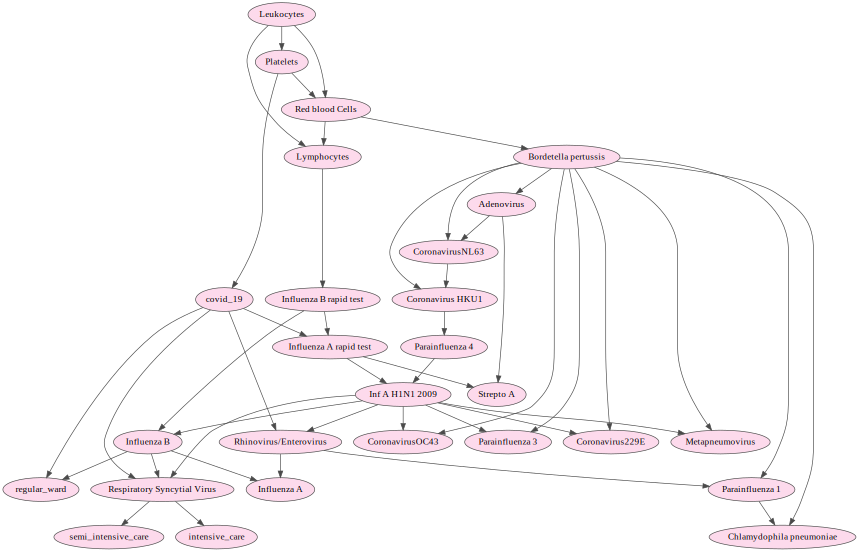

In [75]:
gnb.showBN(clf.bn, size=12, nodeColor={n:0.8 for n in clf.bn.names()})

La estructura aprendida puede contener algunas relaciones que no tienen sentido desde un punto de vista práctico. **El experto en el dominio** puede intervenir para codificar el conocimiento del negocio en el proceso de aprendizaje mediante los arcos tabú o arcos obligados.

En la siguiente celda le decimos al algoritmo que **nunca** dibuje una flecha de

Influenza B ----> covid_19.

También que **siempre incluya** estas dos flechas:

Coronavirus HKu1 ---> Covid_19

Respiratory Syncytial Virus ---> Covid_19



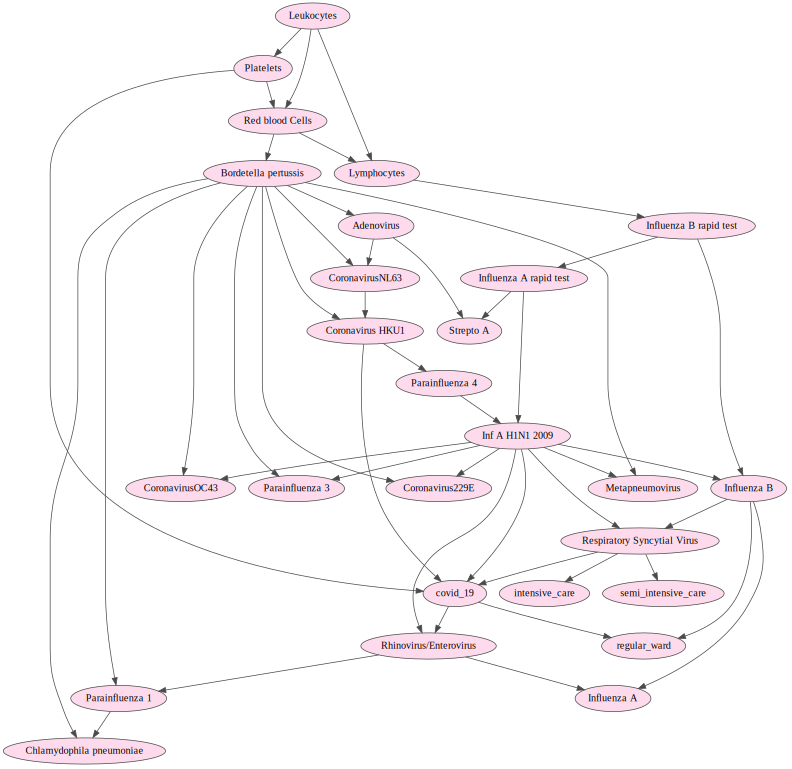

In [76]:
df.to_csv('template.csv', index = False)

clf = BNEstimator(csv_template='template.csv', class_name='intensive_care', ### <--- OJO: Aquí cambié la variable objetivo
                  tabu_arcs=[('Influenza B rapid test', 'covid_19')],  ###  Notemos la incorporación de tabu_arcs
                  mandatory_arcs=[('Coronavirus HKU1','covid_19'),('Respiratory Syncytial Virus','covid_19')],
                  cut_points_percentiles = [5, 50, 95])
_,data = clf.transform(df)

train,test = train_test_split(data ,test_size=0.25, random_state=42)
train.to_csv('train.csv',index=False) ### Guardamos train y test
test.to_csv('test.csv',index=False)

clf.fit(train)

gnb.showBN(clf.bn,size=11,nodeColor={n:0.8 for n in clf.bn.names()})

In [77]:
### Podemos obtener las tablas CPT

for name in clf.bn.names():
    print(f"\n{'='*40}")
    print(f"CPT de: {name}")
    print('='*40)
    print(clf.bn.cpt(clf.bn.idFromName(name)))


CPT de: Parainfluenza 1

             ||  Parainfluenza 1            |
Bordet|Rhinov||-999     |not_detec|detected |
------|------||---------|---------|---------|
-999  |-999  || 1.0000  | 0.0000  | 0.0000  |
not_de|-999  || 0.3333  | 0.3333  | 0.3333  |
detect|-999  || 0.3333  | 0.3333  | 0.3333  |
-999  |not_de|| 0.3333  | 0.3333  | 0.3333  |
not_de|not_de|| 0.0000  | 0.9959  | 0.0041  |
detect|not_de|| 0.0333  | 0.9333  | 0.0333  |
-999  |detect|| 0.3333  | 0.3333  | 0.3333  |
not_de|detect|| 0.0001  | 0.9997  | 0.0001  |
detect|detect|| 0.3333  | 0.3333  | 0.3333  |


CPT de: Rhinovirus/Enterovirus

             ||  Rhinovirus/Enterovirus     |
covid_|Inf A ||-999     |not_detec|detected |
------|------||---------|---------|---------|
0     |-999  || 1.0000  | 0.0000  | 0.0000  |
1     |-999  || 0.9997  | 0.0002  | 0.0002  |
0     |not_de|| 0.0001  | 0.6969  | 0.3030  |
1     |not_de|| 0.0007  | 0.9617  | 0.0376  |
0     |detect|| 0.0007  | 0.9311  | 0.0682  |
1     |detect|| 0.33

### Observaciones de las tablas

- La CPT de covid_19 tiene muchísimas filas con 0.5/0.5, lo que significa que la red no aprendió nada útil para esas combinaciones.

- El patrón 0.3333 indica datos insuficientes (sus padres tienen muchos -999)

(En general, Para mejorar las probabilidades de los puntos anteriores podemos establecer un suvizado de Laplace
)

- Leukocytes no tiene padres, es el único nodo con una sola fila. El 89.9 % de los pacientes tiene leucocitos en rango normal que es 2.0.

- intensive_care y semi_intensive_care tienen las CPT más interpletables. RSV detectado multiplica por 10 la probabilidad de ingreso grave.





*Sugerencia*:



```
df.to_csv('template.csv', index=False)

clf = BNEstimator(csv_template='template.csv',
                  class_name='intensive_care',
                  tabu_arcs=[('Influenza B rapid test', 'covid_19')],
                  mandatory_arcs=[('Coronavirus HKU1','covid_19'),
                                  ('Respiratory Syncytial Virus','covid_19')],
                  prior='laplace',        # ← Activamos el suavizado
                  prior_weight=0.5,       # ← Peso del prior (α)
                  cut_points_percentiles=[5, 50, 95])

_, data = clf.transform(df)

train, test = train_test_split(data, test_size=0.25, random_state=42)
train.to_csv('train.csv', index=False)
test.to_csv('test.csv', index=False)

clf.fit(train)
```



Observemos que en efecto tenemos un DAG

In [78]:
# # Verificar que es un DAG comprobando que no hay ciclos
print(clf.bn.arcs())

{(21, 10), (4, 0), (22, 11), (21, 13), (21, 19), (6, 24), (22, 14), (22, 20), (22, 17), (22, 23), (8, 0), (17, 12), (8, 3), (10, 9), (5, 22), (13, 11), (7, 4), (21, 0), (14, 0), (4, 5), (21, 15), (22, 16), (5, 6), (8, 2), (22, 19), (14, 18), (0, 1), (11, 16), (10, 8), (17, 26), (0, 13), (24, 10), (25, 21), (24, 25), (7, 6), (21, 8), (18, 21), (21, 23), (12, 14), (22, 12), (21, 20), (22, 15), (10, 1), (13, 9), (7, 5), (25, 26)}


In [79]:
# Ver todos los arcos con su dirección
for arc in clf.bn.arcs():
    print(f"{clf.bn.variable(arc[0]).name()} → {clf.bn.variable(arc[1]).name()}")

Inf A H1N1 2009 → Influenza B
Platelets → covid_19
Bordetella pertussis → Parainfluenza 1
Inf A H1N1 2009 → Rhinovirus/Enterovirus
Inf A H1N1 2009 → Coronavirus229E
Lymphocytes → Influenza B rapid test
Bordetella pertussis → Coronavirus HKU1
Bordetella pertussis → CoronavirusOC43
Bordetella pertussis → Adenovirus
Bordetella pertussis → Metapneumovirus
Respiratory Syncytial Virus → covid_19
Adenovirus → CoronavirusNL63
Respiratory Syncytial Virus → intensive_care
Influenza B → Influenza A
Red blood Cells → Bordetella pertussis
Rhinovirus/Enterovirus → Parainfluenza 1
Leukocytes → Platelets
Inf A H1N1 2009 → covid_19
Coronavirus HKU1 → covid_19
Platelets → Red blood Cells
Inf A H1N1 2009 → Parainfluenza 3
Bordetella pertussis → Chlamydophila pneumoniae
Red blood Cells → Lymphocytes
Respiratory Syncytial Virus → semi_intensive_care
Bordetella pertussis → Coronavirus229E
Coronavirus HKU1 → Parainfluenza 4
covid_19 → regular_ward
Parainfluenza 1 → Chlamydophila pneumoniae
Influenza B → Resp

Podemos calcular el tamaño de la JPD  completa. (El producto de todas las CPT)

In [80]:
print(f"Tamaño de la JPD: {get_jpd_size(clf.bn):,} entradas")
print(f"Tamaño de las CPTs: {get_cpts_size(clf.bn):,} entradas")
print(f"Ratio de compresión: {compression_ratio(clf.bn):.2f}%")

Tamaño de la JPD: 6,347,497,291,776 entradas
Tamaño de las CPTs: 817 entradas
Ratio de compresión: 100.00%


## El caso de la guardia regular

Ahora, podemos observar las **probabilidades condicionales** aprendidas por el modelo.

Por ejemplo, para la variable `regular_ward` (que representa ingreso a la guardia normal cuando vale 1 y cero en el caso contrario) tenemos:

$$ \mathbb{P}(regular\_ward \mid covid\_19) $$

In [81]:
clf.bn.cpt(clf.bn.idFromName('regular_ward'))

(pyagrum.Tensor@0x12686100) 
             ||  regular_ward     |
Influe|covid_||0        |1        |
------|------||---------|---------|
-999  |0     || 0.9975  | 0.0025  |
not_de|0     || 0.9705  | 0.0295  |
detect|0     || 0.9983  | 0.0017  |
-999  |1     || 0.9795  | 0.0205  |
not_de|1     || 0.7495  | 0.2505  |
detect|1     || 0.9286  | 0.0714  |

Y podemos escoger visualizar sábanas de Markov.

In [82]:
gum.MarkovBlanket(clf.bn,'covid_19')

<pyagrum.pyagrum.MarkovBlanket; proxy of <Swig Object of type 'gum::MarkovBlanket *' at 0x7e3d61c11e00> >

Interpretemos la tabla de arriba hacia abajo:

- Test negativo de covid y sin datos de influenza tipo B, tiene casi nulas probabilidades de ingresar a la guardia.

- Negativo a covid y negativo a influenza, tiene muy pocas probabilidades de ingresar a la guardia.

- Negativo a covid y positivo a influenza, igualmente tiene muy pocas probabilidades de ingresar a la guardia

Pero incluso con covid detectado, vemos que las probabilidades de ingresar a la guardia son muy bajas en todos los casos. Hay solamenteun 25% de probabilidad de que sea ingresado en la guardia dado que tiene Covid.

Aquí sería interesante averiguar qué ocurre en el caso de la unidad de cuidados intensivos

In [83]:
clf.bn.cpt(clf.bn.idFromName('intensive_care'))

(pyagrum.Tensor@0x11aa3c40) 
      ||  intensive_care   |
Respir||0        |1        |
------||---------|---------|
-999  || 0.9984  | 0.0016  |
not_de|| 0.9834  | 0.0166  |
detect|| 0.8383  | 0.1617  |

Junto con su sábana de Markov que es el subrefo del DAG relevante para predecir la 'intensive_care'

In [84]:
gum.MarkovBlanket(clf.bn, 'intensive_care')

<pyagrum.pyagrum.MarkovBlanket; proxy of <Swig Object of type 'gum::MarkovBlanket *' at 0x7e3d6ffcda10> >

## Red Bayesiana de Distribuciones Marginales


A continuación mostramos las **probabilidades marginales (Conditional Probability *Table*)** de cada variable **sin introducir evidencia**. Lo que el modelo aprende solamente de los datos.

- $P(X | Pa(X_i))$.
- Ciertos nodos raíz $P(X_i)$, donde $X_i$ no tiene padres (como el caso de RSV)

Resalta la muy baja probabilidad de ingreso tanto a la guardia como a la UCI y que ésta no tiene hijos

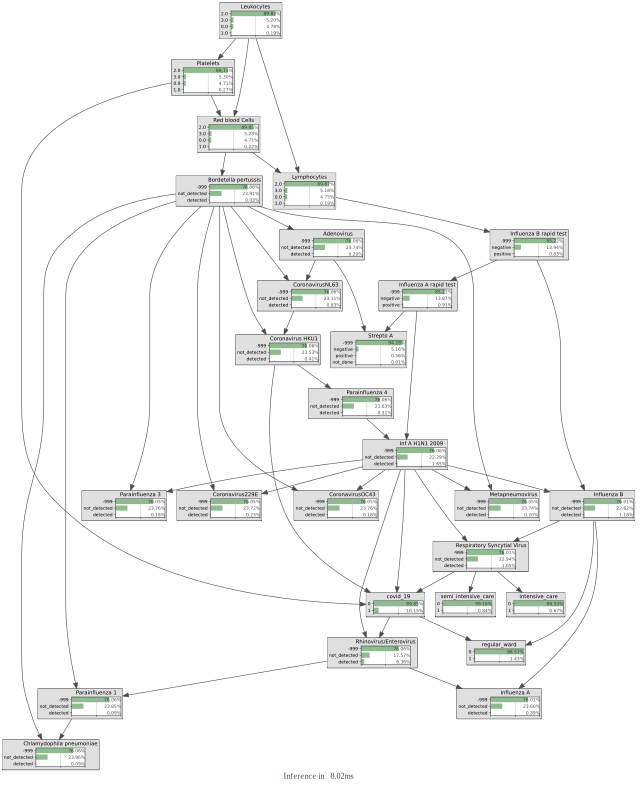

In [85]:
gnb.showInference(clf.bn,size=11)

## Inferencia

Una vez entrenada la Red Bayesiana, podemos usarla para **razonar sobre pacientes concretos**.
Esto es la inferencia bayesiana en acción: dado lo que observamos de un paciente,
¿cuál es la probabilidad de que tenga COVID-19?


Especifiamos el target que queremos analizar, dado un cuadro clínico.

| Variable | Valor observado | Interpretación |
|---|---|---|
| `Platelets` | 2.0 | Plaquetas en rango normal |
| `Influenza B` | detected | Test de gripe B positivo |
| `Coronavirus HKU1` | detected | Coronavirus HKU1 detectado |


En el siguiente ejemplo tenemos

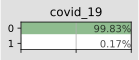

In [86]:
gnb.showPosterior(clf.bn, evs={'Platelets':'2.0', 'Influenza B':'detected',
                               'Coronavirus HKU1':'detected'},
                  target='covid_19')

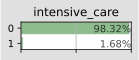

In [87]:
gnb.showPosterior(clf.bn, evs={'Platelets':'2.0', 'Influenza B':'detected',
                               'Coronavirus HKU1':'detected'},
                  target='intensive_care')   ### <--- OJO: Aquí cambié la variable

## La sábana de Markov del Covid19

In [88]:
gum.MarkovBlanket(clf.bn,'covid_19')

<pyagrum.pyagrum.MarkovBlanket; proxy of <Swig Object of type 'gum::MarkovBlanket *' at 0x7e3d636c8ba0> >

De aquí podemos extraer tres **causas directas** (variables que influyen en el diagnóstico) , dos de ellas forzadas por el Mandatory_arc y la influenza B aprendida por los datos.

Mientras que sus hijos (efectos directos) son casi todos aprendidos por los datos. Veamos otro ejemplo del test.





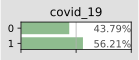

In [96]:
### Seleccionamos un paciente del conjunto test

d_test = pd.read_csv('test.csv')
row = d_test.loc[1,:]
evs = row.astype(str).to_dict()

evidence = {'Platelets': '3.0',
            'Inf A H1N1 2009': 'not_detected',
            'Influenza B': 'detected',
            'Respiratory Syncytial Virus': 'detected',
            'Coronavirus HKU1': 'detected',
            'Rhinovirus/Enterovirus': 'not_detected',
            'regular_ward': 0,
            }

gnb.showPosterior(clf.bn,
                 target='covid_19', ### <<<--: OJO Cambié la variable
                 evs=evidence)

A continuación tomamos la Markov Blanket de Covid_19

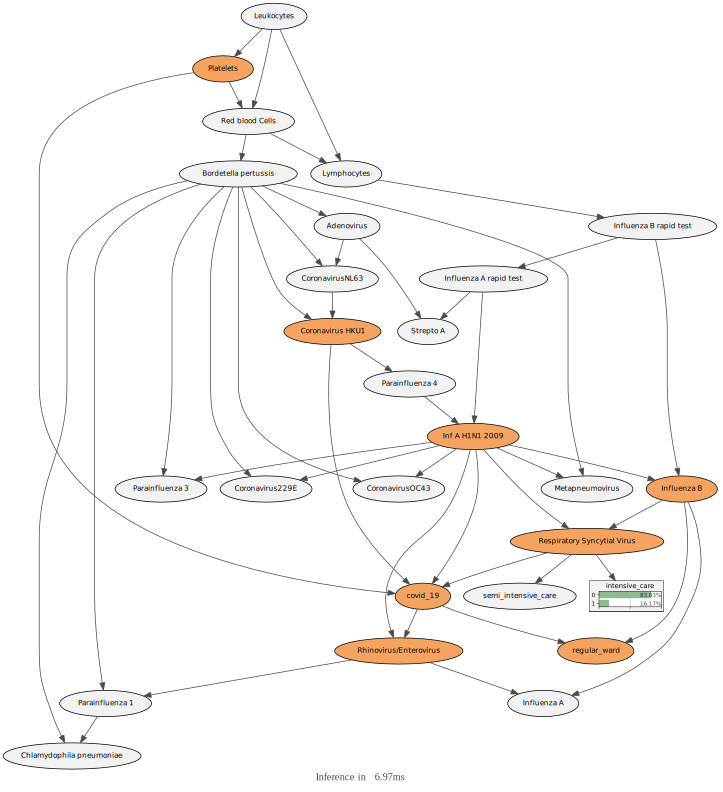

In [90]:
MB = gum.MarkovBlanket(clf.bn,'covid_19')

gnb.showInference(clf.bn,
                  nodeColor={n:0.9 for n in clf.bn.names()},
                  evs=evidence,
                  targets={'intensive_care'}, ### <<<---- Intensive care
                  size=11)

otro caso ficticio pero con datos fuera de la Markov Blanket de Covid_19.

Vemos que arroja el mismo resultado que antes, lo que significa que toda la información relevante para predecir la variable está dentro de su Markov Blanket

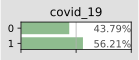

In [98]:
from  random import choice
id = choice(list(clf.bn.nodes().difference(MB.nodes()))) ### Añade variables que no están en la lista de las variables de la manta de manera aleatoria
gnb.showPosterior(clf.bn,
                  evs={'Platelets': '3.0',
                        'Inf A H1N1 2009': 'not_detected',
                        'Influenza B': 'detected',
                        'Respiratory Syncytial Virus': 'detected',
                        'Coronavirus HKU1': 'detected',
                        'Rhinovirus/Enterovirus': 'not_detected',
                       'regular_ward': 0,
                      clf.bn.variable(id).name():1},
                  target= 'covid_19')

Dos variables irrelevantes no afectan la probabilidad

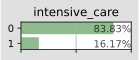

In [92]:
from  random import choice
id1 = choice(list(clf.bn.nodes().difference(MB.nodes())))
id2 = choice(list(clf.bn.nodes().difference(MB.nodes())))

gnb.showPosterior(clf.bn, # we specify the BN to reason with
                  evs={'Platelets': '3.0',
                        'Inf A H1N1 2009': 'not_detected',
                        'Influenza B': 'detected',
                        'Respiratory Syncytial Virus': 'detected',
                        'Coronavirus HKU1': 'detected',
                        'Rhinovirus/Enterovirus': 'not_detected',
                       'covid_19' : 0,
                      clf.bn.variable(id1).name():1,
                      clf.bn.variable(id2).name():0},  ## observe outside of MB
                  target= 'intensive_care')

## Consideraciones de almacenamiento

Sobre el tamaño de jpd y cpts

In [93]:
### Número de entradas que tendría la tabla de distribución conjunta completa JPD

get_jpd_size(clf.bn) # P(v1, v2, ..., vn)

np.int64(6347497291776)

In [94]:
### Calcula el tamaño de las CPT

get_cpts_size(clf.bn) # P(vi | v1, ..., vk)

np.int64(817)

In [95]:
## Radio de compresión. Un ratio del 99% significa que la red usa solo el 1% del espacio que necesitaría la JPD completa.

compression_ratio(clf.bn)

np.float64(99.99999998712879)

## Referencias

- https://github.com/AlvaroCorrales/BayesianNetworks/blob/main/Bayesian_Networks_Tutorial_covid-19.ipynb
- https://pyagrum.readthedocs.io/en/latest/notebooks/31-Learning_structuralLearning.html
- https://www.nature.com/articles/s41598-023-28123-z
- https://en.m.wikipedia.org/wiki/Markov_blanket